c:\Users\Nils\nn_stochvol_calibrations\generation\utils.py:233: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["expiration"] = pd.to_datetime(df["expiration"])


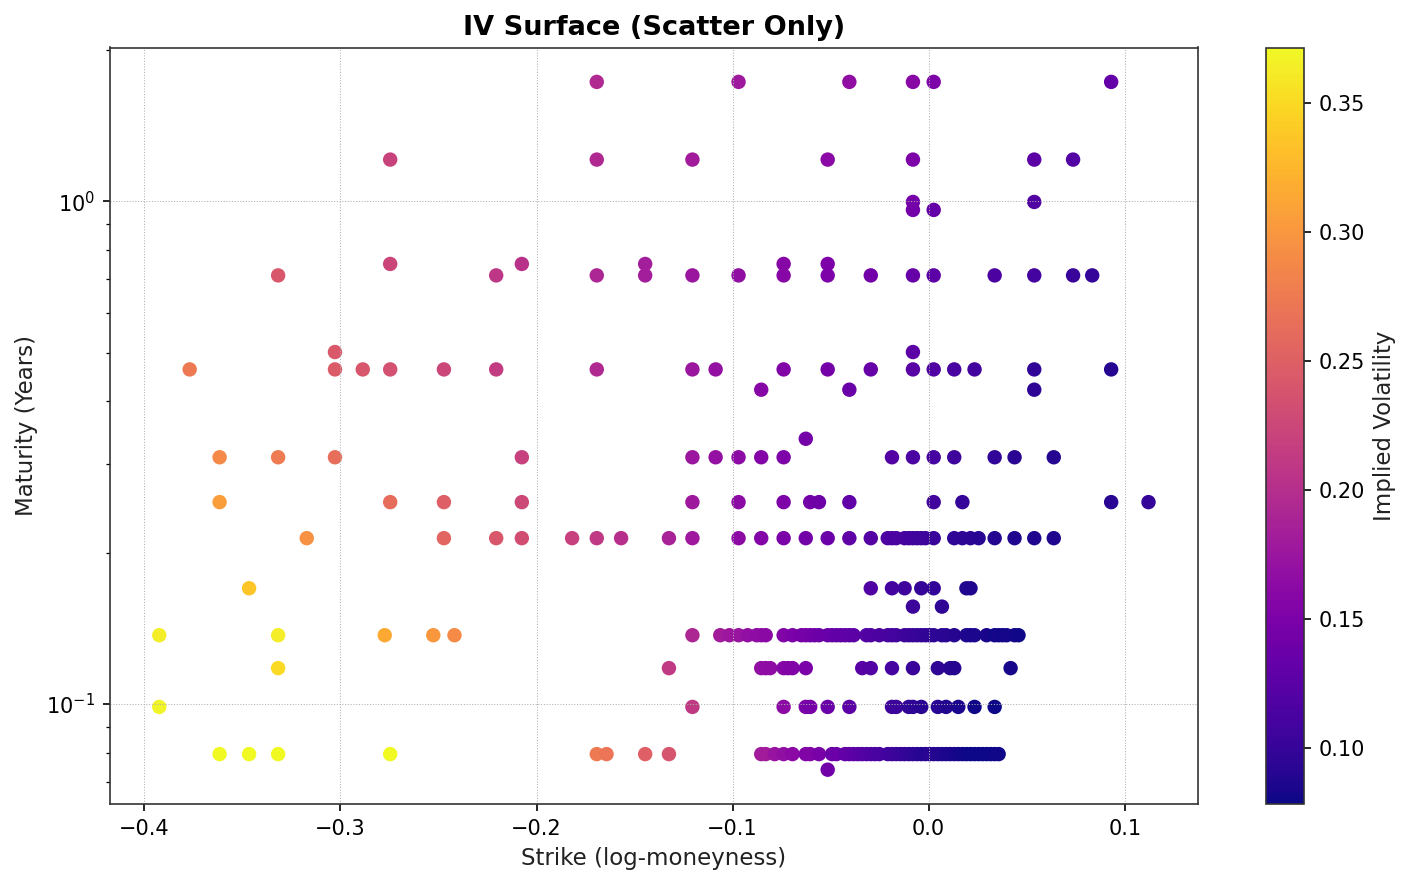

In [1]:
import pandas as pd
import numpy as np
import sys, os
from typing import List, Tuple


sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from generation.utils import plot_iv_surface_scatter, preprocess_and_filter_otm, build_market_surfaces
from models.framework import DeepONet

df = pd.read_csv("C:/Users/Nils/nn_stochvol_calibrations/real_calibration/Raw IV_US_Canada.csv")
df = preprocess_and_filter_otm(df)
surfaces = build_market_surfaces(df)
plot_iv_surface_scatter(surfaces[0]["iv_surface"],surfaces[0]["grid"]["strikes"],np.exp(surfaces[0]["grid"]["maturities"]))

In [2]:
model_path="C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/deeponet.pth"
x = DeepONet.load(model_path)
x.calibrate(surfaces[0], optimiser="lm", maxiter=1000)

✅ Loaded DeepONet from C:/Users/Nils/nn_stochvol_calibrations/training/saved_models/deeponet.pth


c:\Users\Nils\nn_stochvol_calibrations\models\framework.py:706: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.jacrev` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.func.jacrev` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  J_fn = jacrev(f_single)


{'theta_hat': array([ 3.05374762, -0.95849411,  0.0563516 ,  0.01241504,  0.02495962,
         0.03555508,  0.06897858,  0.00850127,  0.15953585,  0.15841202,
         0.01846663]),
 'error_rel_dict': {'eta': 0.0,
  'rho': 0.0,
  'H': 0.0,
  'xi0_0': 0.0,
  'xi0_1': 0.0,
  'xi0_2': 0.0,
  'xi0_3': 0.0,
  'xi0_4': 0.0,
  'xi0_5': 0.0,
  'xi0_6': 0.0,
  'xi0_7': 0.0},
 'rmse': 0.007888060063123703,
 'runtime_ms': 18765.499900000577,
 'optimizer': 'lm'}

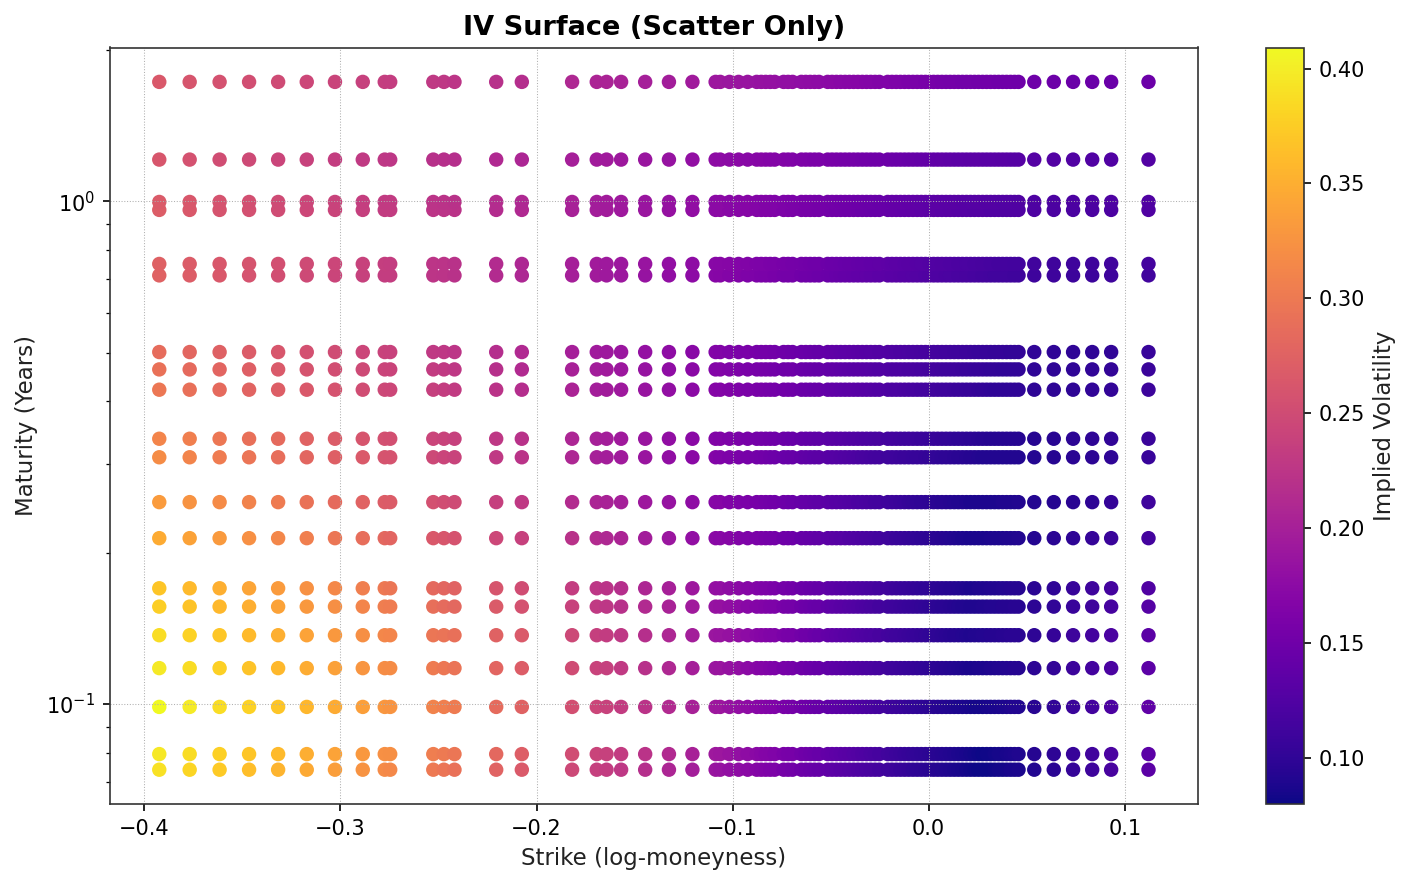

In [3]:
params = {'eta': 3.0537476,
 'rho': -0.95849411,
 'H': 0.0563516,
 'xi0_knots': [0.01241504,  0.02495962,
         0.03555508,  0.06897858,  0.00850127,  0.15953585,  0.15841202,
         0.01846663]}

k = x.predict_surface(params, grid=surfaces[0]["grid"]).detach().numpy()
plot_iv_surface_scatter(k,surfaces[0]["grid"]["strikes"],np.exp(surfaces[0]["grid"]["maturities"]))

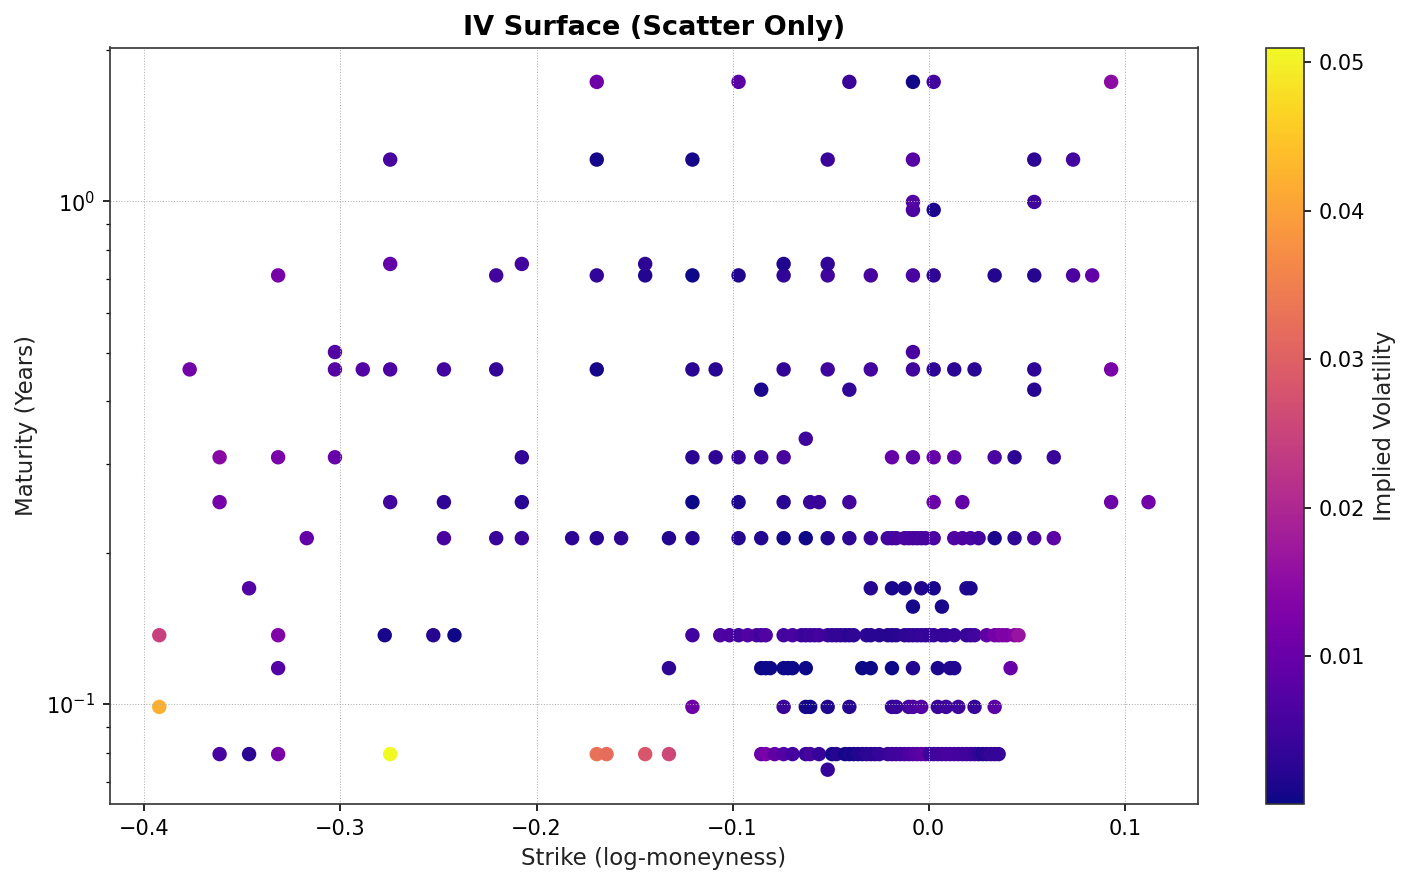

In [4]:
plot_iv_surface_scatter(np.abs(k-surfaces[0]["iv_surface"]),surfaces[0]["grid"]["strikes"],np.exp(surfaces[0]["grid"]["maturities"]))